<h1><font color="#113A68" size=6> Visualización de capas  </font></h1>

En este proyecto se mostrará la vizualización de capas ocultas en una CNN.


# Modelo

In [1]:
!ls

imagenes  sample_data


In [2]:
%pip install np_utils

In [3]:
# Librerias
import pandas as pd
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Flatten
from keras.layers  import Conv2D
from keras.layers  import MaxPooling2D
#from keras.utils import np_utils
from tensorflow.keras.utils import to_categorical
import numpy as np

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input


In [4]:
#Librerias adicionales
import numpy as np
import random
from tensorflow.keras.preprocessing.image import img_to_array, load_img
import tensorflow

In [5]:
from tensorflow.keras import Model, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Definir la entrada
input_layer = Input(shape=(128, 128, 3))

# Modelo
layer = Conv2D(10, (3,3), activation='relu')(input_layer)
layer = MaxPooling2D(2, 2)(layer)
layer = Conv2D(6, (3,3), activation='relu')(layer)
layer = MaxPooling2D(2,2)(layer)
layer = Flatten()(layer)
layer = Dense(128, activation='relu')(layer)
output_layer = Dense(1, activation='sigmoid')(layer)

# Crear el modelo
model = Model(inputs=input_layer, outputs=output_layer)

# Visualización de salidas
layer_outputs = [layer.output for layer in model.layers]
visualize_model = Model(inputs=model.input, outputs=layer_outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 6)      │           546 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       691,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 692,283 (2.64 MB)

 Trainable params: 692,283 (2.64 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Cargar imagen para predicción
img=load_img('./imagenes/nueve.jpg',target_size=(128,128))

In [7]:
# Convertir imagen en arreglo
x = img_to_array(img)

In [8]:
# Imprimir las dimensiones del arreglo
x.shape

(128, 128, 3)

In [9]:
# Reshape image
x=x.reshape((1,128,128,3))
print(x.shape)

(1, 128, 128, 3)


In [10]:
# Rescale the image
x = x /255

In [11]:
x.shape

(1, 128, 128, 3)

In [12]:
# Obtenga los mapas de características de todas las capas para la imagen
feature_maps=visualize_model.predict(x)
print(len(feature_maps))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 737ms/step
8


In [13]:
# Mostrar nombres de capas definidas en el modelo
layer_names = [layer.name for layer in model.layers]
print(layer_names)

['input_layer', 'conv2d', 'max_pooling2d', 'conv2d_1', 'max_pooling2d_1', 'flatten', 'dense', 'dense_1']


### Visualización de capas

In [14]:
# Libraries adicionales
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

(1, 128, 128, 3)
(1, 126, 126, 10)
(1, 63, 63, 10)
(1, 61, 61, 6)
(1, 30, 30, 6)
(1, 5400)
(1, 128)
(1, 1)


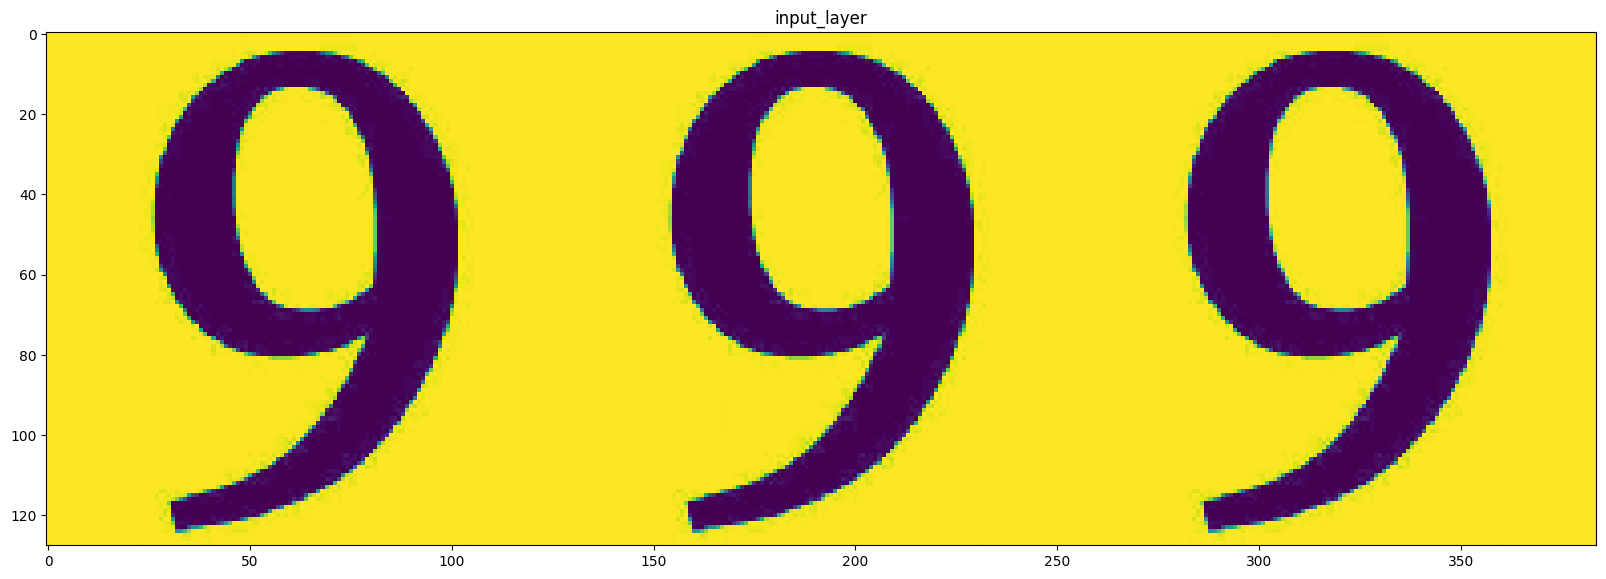

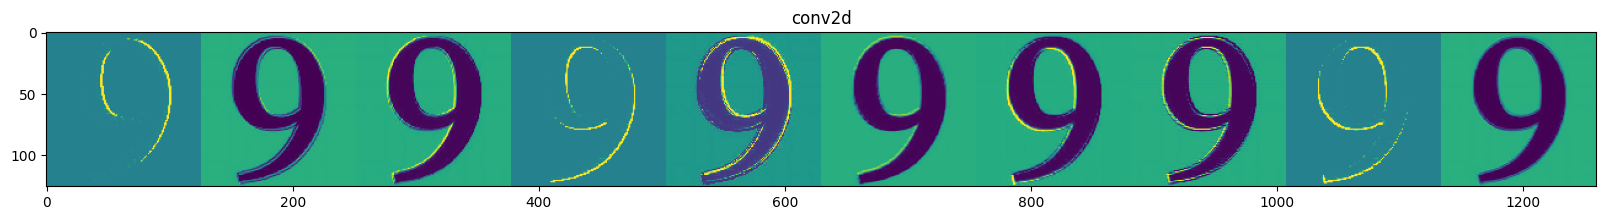

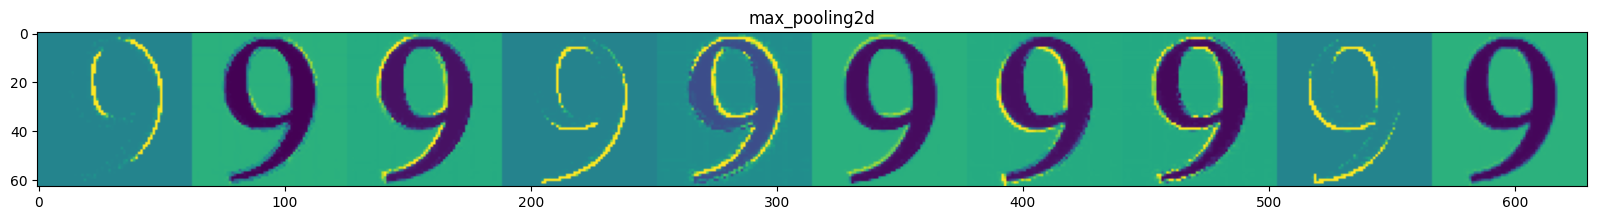

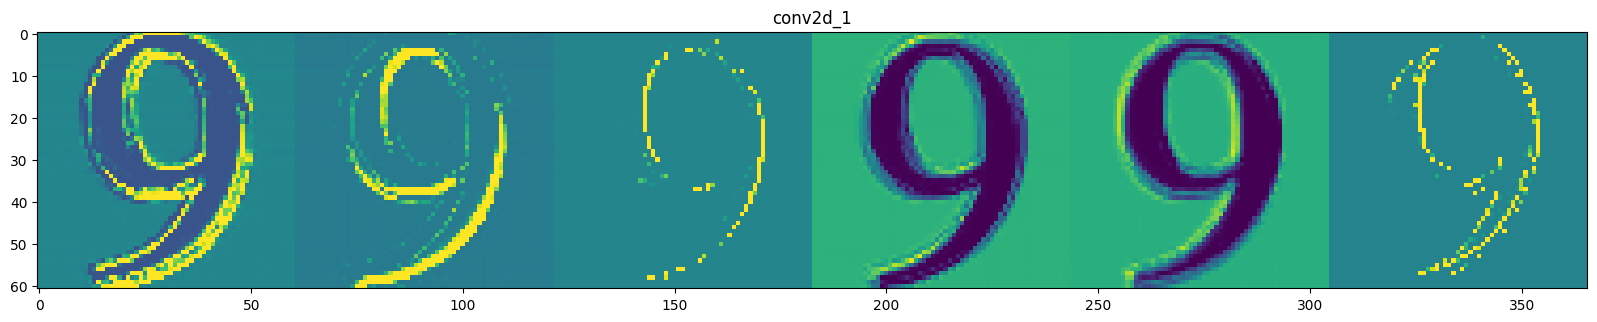

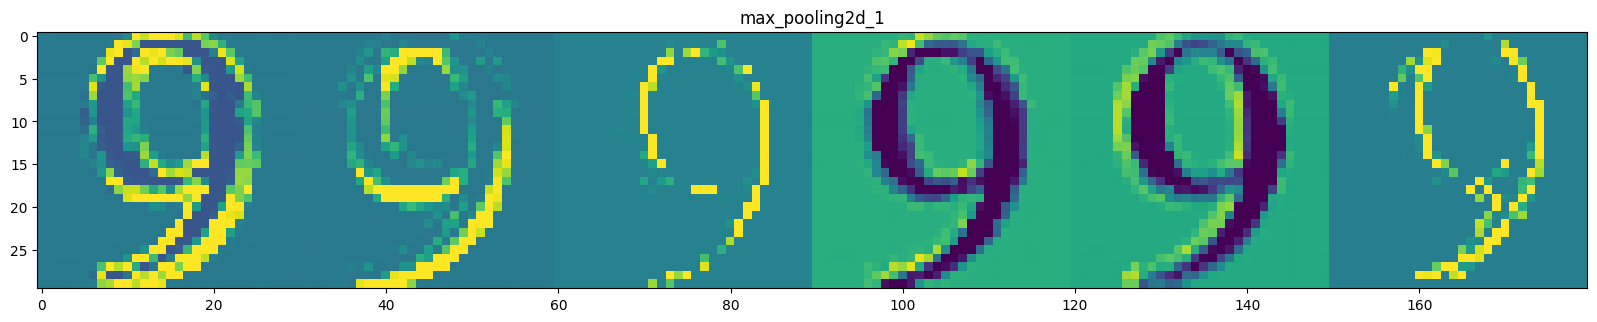

In [15]:
# Plotting
for layer_names, feature_maps in zip(layer_names,feature_maps):
  print(feature_maps.shape)
  if len(feature_maps.shape) == 4 :
    channels = feature_maps.shape[-1]
    size = feature_maps.shape[1]
    display_grid = np.zeros((size, size * channels))
    for i in range(channels):
      epsilon = 1e-7  # Valor muy pequeño
      x = feature_maps[0, :, :, i]
      x -= x.mean()
      #x /= x.std()
      x /= (x.std() + epsilon)  # Sumar epsilon para evitar división por cero
      x *= 64
      x += 128
      x = np.clip(x, 0, 255).astype('uint8')
      # We'll tile each filter into this big horizontal grid
      display_grid[:, i * size : (i + 1) * size] = x

    scale = 20. / channels
    plt.figure(figsize=(scale * channels, scale))
    plt.title(layer_names)
    plt.grid(False)
    plt.imshow(display_grid, aspect='auto', cmap='viridis')

### Visualización de filtros

In [16]:
filters = model.layers[2].get_weights()

In [17]:
#print(filters);

conv2d
10


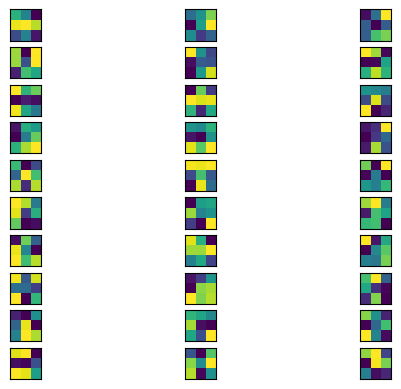

conv2d_1
6


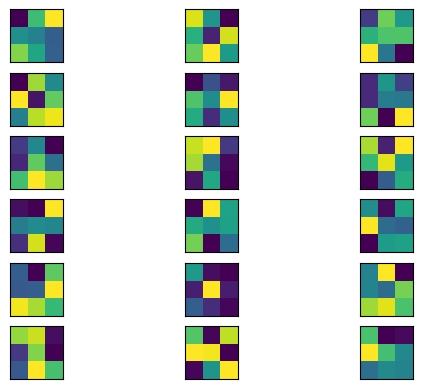

In [18]:
for layer in model.layers:
    if 'conv' in layer.name:
        weights, bias= layer.get_weights()
        print(layer.name)

        #normalize filter values between  0 and 1 for visualization
        f_min, f_max = weights.min(), weights.max()
        filters = (weights - f_min) / (f_max - f_min)
        print(filters.shape[3])
        filter_cnt=1

        #plotting all the filters
        for i in range(filters.shape[3]):
            #get the filters
            filt=filters[:,:,:, i]
            #plotting each of the channel, color image RGB channels
            for j in range(filters.shape[0]):
                ax= plt.subplot(filters.shape[3], filters.shape[0], filter_cnt  )
                ax.set_xticks([])
                ax.set_yticks([])
                plt.imshow(filt[:,:, j])
                #print(filt[:,:, j])
                filter_cnt+=1
        plt.show()

Referencias



https://towardsdatascience.com/conv2d-to-finally-understand-what-happens-in-the-forward-pass-1bbaafb0b148